# Tutorial: **δHBV 1.1p**

---

This notebook demonstrates training and forward simulation with the δHBV 1.1p model developed by [Yalan Song et al. (2025)](https://doi.org/10.22541/essoar.172304428.82707157/v2). A pre-trained model is provided for those who only wish to run the model forward.

For explanation of model structure, methodologies, data, and performance metrics, please refer to Song's publication [below](#publication). If you find this code is useful in your own work, please include the aforementioned citation.

**Note**: If you are new to the dMG framework, we suggest first looking at our [δHBV 1.0 tutorial](./../hydrology/example_dhbv.ipynb).

<br>

### Before Running:
- **Environment**: See [setup.md](./../../docs/setup.md) for ENV setup. dMG must be installed with dependencies + hydrodl2 to run this notebook.

- **Model**: Download pretrained δHBV 1.1p model weights from [AWS](https://mhpi-spatial.s3.us-east-2.amazonaws.com/mhpi-release/models/dhbv_1_1p_trained.zip). Then update the model config:

    - In [`./generic_deltamodel/example/conf/config_dhbv_1_1p.yaml`](./../conf/config_dhbv_1_1p.yaml), update *trained_model* with your path to the parent directory containing both trained model weights `dhbv_1_1p_ep50.pt` (or *Ep100*) **and** normalization file `normalization_statistics.json`.
    - **Note**: make sure this path includes the last closing forward slash: e.g., `./your/path/to/model/`.

- **Data**: Download the CAMELS data extraction from [AWS](https://mhpi-spatial.s3.us-east-2.amazonaws.com/mhpi-release/camels/camels_data.zip). Then, updated the data configs:

    - In [`./generic_deltamodel/example/conf/observations/camels_531.yaml`](./../conf/observations/camels_531.yaml) and [`camels_671.yaml`](./../conf/observations/camels_671.yaml), update...
        1. *data_path* with `camels_dataset` path,
        2. *gage_info* with `gage_ids.npy` path,
        3. *subset_path* with `531_subset.txt` path (camels_531 only).

    - The full 671-basin or 531-basin CAMELS datasets can be selected by setting `observations: camels_671` or `camels_531` in the model config, respectively.

- **Hardware**: The NNs used in this model require CUDA support only available with Nvidia GPUs. For those without access, T4 GPUs can be used when running this notebook with dMG on [Google Colab](https://colab.research.google.com/).

<br>

### Publication:

*Yalan Song, Kamlesh Sawadekar, Jonathan M Frame, Ming Pan, Martyn Clark, Wouter J M Knoben, Andrew W Wood, Trupesh Patel, Chaopeng Shen. "Physics-informed, Differentiable Hydrologic  Models for Capturing Unseen Extreme Events." ESS Open Archive (2025). https://doi.org/10.22541/essoar.172304428.82707157/v2.*

<br>

### Issues:
For questions, concerns, bugs, etc., please reach out by posting an [issue](https://github.com/mhpi/generic_deltamodel/issues).

---


<br>

## 1. Forward δHBV 1.1p

After completing [these](#before-running) steps, forward δHBV 1.1p with the code block below.

Note:
- The settings defined in the config `./generic_deltamodel/example/conf/config_dhbv_1_1p.yaml` are set to replicate benchmark performance on 531 CAMELS basins.
- The first year (`warm_up` in the config, default is 365 days) of the inference period is used for initializing HBV's internal states (water storages) and is, therefore, excluded from the model's prediction output.

### 1.1 Demonstration

In [1]:
import sys
sys.path.append('../../') 
from dmg import ModelHandler 
from dmg.core.utils import import_data_loader, print_config, set_randomseed
from example import load_config 
#------------------------------------------#
# Define model settings here.
CONFIG_PATH = '../example/conf/config_dhbv_1_1p.yaml'
#------------------------------------------#


# 1. Load configuration dictionary of model parameters and options.
config = load_config(CONFIG_PATH)
config['mode'] = 'simulation'
print_config(config)
print("Keys that you can use", config.keys())

# Set random seed for reproducibility.
set_randomseed(config['random_seed'])

# 2. Initialize the differentiable HBV 1.1p model (LSTM + HBV 1.1p).
model = ModelHandler(config, verbose=True)
print("Model keys that you can use", model.model_dict.keys())
 
# 3. Load and initialize a dataset dictionary of NN and HBV model inputs.
data_loader_cls = import_data_loader(config['data_loader'])
data_loader = data_loader_cls(config, test_split=False, overwrite=False)
print("The dataset keys are", data_loader.dataset.keys())

# 4. Forward the model to get the predictions.
output = model(
    data_loader.dataset,
    eval=True,
)

print("-------------\n")   
print(f"Streamflow predictions for {output['Hbv_1_1p']['streamflow'].shape[0]} days and " \
      f"{output['Hbv_1_1p']['streamflow'].shape[1]} basins ~ \nShowing the first 5 days for " \
        f"first basin: \n {output['Hbv_1_1p']['streamflow'][:5,:1].cpu().detach().numpy().squeeze()}")
print(output['Hbv_1_1p'].keys())


Current Configuration
  Experiment Mode:    simulation          
  Model 1:            Hbv_1_1p            

Data Loader
  Data Source:        camels_531          
  Simulation Range :  2012/10/01          2014/09/30          

Model Parameters
  Train Epochs:       50                  Batch Size:         100                 
  Dropout:            0.5                 Hidden Size:        256                 
  Warmup:             365                 Concurrent Models:  16                  
  Loss Fn:            NseBatchLoss        

Machine
  Use Device:         cuda:0              

Keys that you can use dict_keys(['mode', 'random_seed', 'device', 'gpu_id', 'data_loader', 'data_sampler', 'trainer', 'save_path', 'trained_model', 'train', 'test', 'simulation', 'loss_function', 'delta_model', 'observations', 'dtype', 'train_time', 'test_time', 'sim_time', 'experiment_time', 'all_time', 'multimodel_type', 'model_path', 'out_path'])
Model keys that you can use dict_keys(['Hbv_1_1p'])
The d

In [2]:
import torch

def get_parameters_from_model(
    dpl_model,
    data,
    n_par,
    mu,
    device="cpu",
):
    """
    Extract HBV parameters (and routing weights if available) 
    from a trained dPL model.

    Args:
        dpl_model : dmg.models.delta_models.dpl_model.DplModel
            The HBV dPL model wrapper (with nn_model + phy_model).
        data : dict OR torch.Tensor
            Either a dict with {"xc_nn_norm": [T,B,F], "c_nn_norm": [...]},
            or a dataset slice (dict) that already has 'xc_nn_norm' etc.
        n_par : int
            Number of HBV parameters.
        mu : int
            Multiplicity factor (ensemble dimension).
        device : str or torch.device
            Device for computation.

    Returns:
        pars : torch.Tensor [T, B, n_par, mu]
        rtwts: torch.Tensor [B,2] or None
    """
    nn_model = dpl_model.nn_model

    # Allow both dataset dicts and custom-prepared dicts
    if isinstance(data, dict):
        xc_nn = data["xc_nn_norm"].to(device)
        c_nn  = data.get("c_nn_norm", None)
    else:
        raise TypeError("data must be a dict with 'xc_nn_norm' (and optional 'c_nn_norm').")

    with torch.no_grad():
        # Forward through NN
        if type(nn_model).__name__ == "LstmMlpModel":
            out = nn_model(xc_nn, c_nn)
        else:
            out = nn_model(xc_nn)

        if isinstance(out, (tuple, list)):
            out = out[0]

        if not isinstance(out, torch.Tensor):
            raise RuntimeError("NN forward did not return a tensor.")

        T, B, F = out.shape

        # Interpret outputs
        if F == n_par:
            pars = out.unsqueeze(-1).to(device)
            rts  = None
        elif F == n_par * mu:
            pars = out.view(T, B, n_par, mu).to(device)
            rts  = None
        elif F == n_par * mu + 2:
            flat = out[:, :, : n_par * mu]
            pars = flat.view(T, B, n_par, mu).to(device)
            rts  = out[-1, :, n_par * mu : n_par * mu + 2].to(device)
        else:
            raise RuntimeError(
                f"Unexpected feature size {F}, expected {n_par}, {n_par*mu}, or {n_par*mu+2}"
            )

    return pars, rts


In [59]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd

def plot_ensemble_forecast(
    gage_id,
    start_date,
    obs,
    sim,
    ens_preds,
    history_len=60,
    save_path=None,
):
    """
    Plot 2 months history + 15-day forecast:
      - Observed (black)
      - Simulation (red) for history
      - 5 ensembles in distinct colors for forecast
    """
    

    forecast_len = ens_preds.shape[1]
    start_date = pd.to_datetime(start_date)
    dates = pd.date_range(
        start=start_date - pd.Timedelta(days=history_len),
        periods=history_len + forecast_len,
    )
    print("history_len:", history_len)
    print("forecast_len:", forecast_len)
    print("dates len:", len(dates)) 
    print("start_date:", start_date)
    print("period", history_len + forecast_len)

    # Squeeze arrays
    obs = np.squeeze(obs)
    sim = np.squeeze(sim)

    # Build full series for sim (only history is valid)
    sim_full = np.full(history_len + forecast_len, np.nan)
    sim_full[:history_len] = sim[-history_len:]  # last 60 days

    # Pad ensembles for plotting (only forecast period valid)
    padded_ensembles = np.full((ens_preds.shape[0], history_len + forecast_len), np.nan)
    padded_ensembles[:, history_len:] = ens_preds

    # Plot
    plt.figure(figsize=(12, 6))

    # Observed
    plt.plot(dates, obs, "k-", lw=2, label="Observed")

    # Simulation (history only)
    plt.plot(dates, sim_full, "r-", lw=1.5, label="Simulation (history)")

    # Ensembles in distinct colors
    colors = cm.tab10.colors  # 10 distinct colors
    for i in range(ens_preds.shape[0]):
        plt.plot(
            dates,
            padded_ensembles[i],
            lw=1.5,
            color=colors[i % len(colors)],
            label=f"Ensemble {i+1}",
        )

    # Shading for history vs forecast
    plt.axvspan(dates[0], dates[history_len - 1], color="gray", alpha=0.1, label="History")
    plt.axvspan(dates[history_len], dates[-1], color="orange", alpha=0.1, label="Forecast")

    plt.title(f"GEFS Forecast — Gage {gage_id}")
    plt.xlabel("Date")
    plt.ylabel("Streamflow (mm/day)")
    plt.legend(loc="upper left", ncol=2)
    plt.grid(True)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300)
    plt.show()


Using device: cuda
obs shape after fix: torch.Size([15])
[info] c_nn_norm not found, normalizing c_nn manually (z-score)
pars_hist: torch.Size([531, 1, 14, 16])
rtwts_hist: torch.Size([1, 2])
ens 0 raw head (P,T,PET):
[[ 3.162 19.764  1.117]
 [ 4.872 18.528  1.337]
 [ 0.    22.702  1.614]
 [ 0.    23.799  1.372]
 [ 0.    22.429  1.488]]
ens 0: NaNs=15  min=nan  max=nan
ens 1 raw head (P,T,PET):
[[ 6.174 20.736  1.248]
 [ 0.    19.01   1.414]
 [ 0.    22.074  1.585]
 [ 0.    22.644  1.593]
 [ 0.    21.999  1.423]]
ens 1: NaNs=15  min=nan  max=nan


/tmp/ipykernel_4067149/741924801.py:179: RuntimeWarning: All-NaN slice encountered
  f"min={np.nanmin(qs_warm):.4g}  max={np.nanmax(qs_warm):.4g}")
/tmp/ipykernel_4067149/741924801.py:179: RuntimeWarning: All-NaN slice encountered
  f"min={np.nanmin(qs_warm):.4g}  max={np.nanmax(qs_warm):.4g}")


ens 2 raw head (P,T,PET):
[[ 0.42  17.531  1.113]
 [ 8.765 18.949  1.378]
 [ 0.085 22.365  1.595]
 [ 0.    20.803  1.294]
 [ 0.    22.073  1.497]]
ens 2: NaNs=15  min=nan  max=nan
ens 3 raw head (P,T,PET):
[[ 0.    21.476  1.423]
 [ 2.978 18.822  1.351]
 [ 0.    22.276  1.581]
 [ 0.    21.558  1.45 ]
 [ 0.331 22.135  1.405]]
ens 3: NaNs=15  min=nan  max=nan


/tmp/ipykernel_4067149/741924801.py:179: RuntimeWarning: All-NaN slice encountered
  f"min={np.nanmin(qs_warm):.4g}  max={np.nanmax(qs_warm):.4g}")
/tmp/ipykernel_4067149/741924801.py:179: RuntimeWarning: All-NaN slice encountered
  f"min={np.nanmin(qs_warm):.4g}  max={np.nanmax(qs_warm):.4g}")


ens 4 raw head (P,T,PET):
[[ 0.    15.024  1.191]
 [ 0.    19.202  1.428]
 [ 0.    22.162  1.58 ]
 [ 0.    23.385  1.307]
 [ 0.351 23.206  1.254]]
ens 4: NaNs=15  min=nan  max=nan
warm_fcst shape: (5, 15)
history_len: 60
forecast_len: 15
dates len: 75
start_date: 2014-09-01 00:00:00
period 75


/tmp/ipykernel_4067149/741924801.py:179: RuntimeWarning: All-NaN slice encountered
  f"min={np.nanmin(qs_warm):.4g}  max={np.nanmax(qs_warm):.4g}")


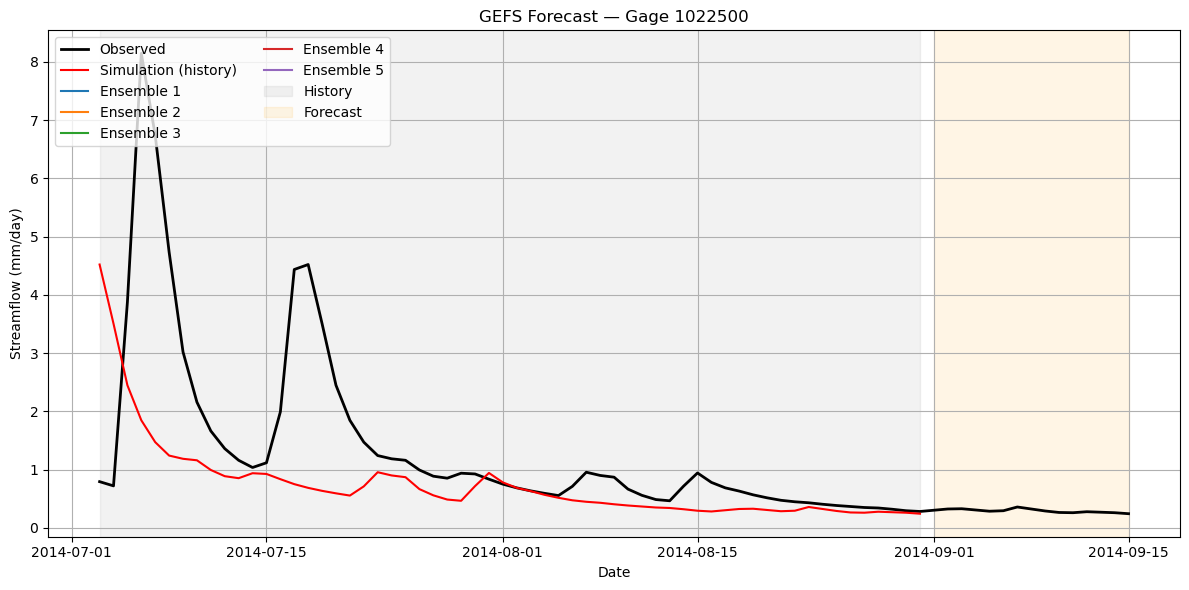

In [61]:
# ==== Warm-start GEFS forecast: single cell ====

import os
import json
import numpy as np
import pandas as pd
import torch
from src.dmg.core.utils import Dates
import helper as hp
from hydrodl2.models.hbv import HBV1_1p as h1pp

# ---------------- SETTINGS ---------------- #
GAGE_ID     = 1022500
START_DATE  = pd.to_datetime("2014-09-01")
HORIZON     = 15
N_ENSEMBLES = 5
device      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# GEFS files have these column names after rename
VAR_F = ["prcp", "tmean", "pet"]
GEFS_DIR = "/u/st/dr/awwood/aw-ciroh-proj/projects/dl_da/daymet-gefs-camels-gII"

# HBV options (match training/config)
staind   = -1
tdRep    = [1, 3, 13]
BUFFTIME = 365
routing  = True
comprout = False
dydrop   = 0.0

# ---------------- Basin index ---------------- #
gage_ids = np.load(config["observations"]["gage_info"], allow_pickle=True)
subset_file = config["observations"]["subset_path"]
with open(subset_file, "r") as f:
    content = f.read().strip()
gage_ids_subset = json.loads(content) if content.startswith("[") else np.loadtxt(subset_file, dtype=int).tolist()

if config["observations"]["name"] == "camels_671":
    basin_idx = list(gage_ids).index(GAGE_ID)
elif config["observations"]["name"] == "camels_531":
    basin_idx = list(gage_ids_subset).index(GAGE_ID)
else:
    raise ValueError(f"Unsupported dataset {config['observations']['name']}")

# ---------------- Time axis ---------------- #
timesteps = Dates(config["simulation"], config["delta_model"]["rho"]).batch_daily_time_range
sidx = np.where(timesteps == START_DATE)[0][0]
eidx = sidx + HORIZON

# ---------------- Dataset ---------------- #
dataset = data_loader.dataset
print("obs shape after fix:", dataset["target"][sidx:eidx, basin_idx, 0].shape)  # (15,)

# ---------------- HBV setup ---------------- #
hbv = h1pp.HBV().to(device)

def to_time_first(x_torch):
    return x_torch.permute(1, 0, 2).float().to(device)  # [T,B,F]

# ---------------- Static attributes ---------------- #
if "c_nn_norm" in dataset:
    c_nn_all = dataset["c_nn_norm"]
else:
    print("[info] c_nn_norm not found, normalizing c_nn manually (z-score)")
    c_nn = dataset["c_nn"].float()
    mask = ~torch.isnan(c_nn)
    mean = torch.sum(torch.where(mask, c_nn, torch.zeros_like(c_nn)), dim=0, keepdim=True) / mask.sum(dim=0, keepdim=True).clamp(min=1)
    var  = torch.sum(torch.where(mask, (c_nn - mean)**2, torch.zeros_like(c_nn)), dim=0, keepdim=True) / mask.sum(dim=0, keepdim=True).clamp(min=1)
    std  = torch.sqrt(var)
    c_nn_all = (torch.where(mask, c_nn, mean) - mean) / (std + 1e-6)

c_nn_hist = c_nn_all[basin_idx:basin_idx+1, :].to(device)

# ---------------- History (up to START_DATE) ---------------- #
# Use the already-normalized inputs used during training for parameterization,
# but HBV physics will be driven by RAW forcings (see forecast step).
xc_nn_hist = dataset["xc_nn_norm"][basin_idx:basin_idx+1, :sidx, :].clone().float()
xc_nn_hist[torch.isnan(xc_nn_hist)] = 0.0

if "c_nn_norm" in dataset:
    c_nn_hist = dataset["c_nn_norm"][basin_idx:basin_idx+1, :].to(device).float()
else:
    c_nn_hist = c_nn_all[basin_idx:basin_idx+1, :].to(device).float()

hist_dict = {
    "xc_nn_norm": to_time_first(xc_nn_hist),  # [Th,1,F]
    "c_nn_norm": c_nn_hist,                   # [1,F_attr]
}

# --- Get parameters from trained NN (time sequence over history) ---
pars_hist, rtwts_hist = get_parameters_from_model(
    model.model_dict["Hbv_1_1p"],
    hist_dict,
    n_par=14,
    mu=config["delta_model"]["phy_model"]["nmul"],
    device=device,
)
print("pars_hist:", pars_hist.shape)
print("rtwts_hist:", None if rtwts_hist is None else rtwts_hist.shape)

# --- Warm-up HBV to get end-of-history states (physics expects RAW forcings; here history is already in the model's internal pipeline) ---
with torch.no_grad():
    Qs_hist, sp, mw, sm, suz, slz = hbv(
        x=hist_dict["xc_nn_norm"][:, :, :3],  # here this matches how your dataset was built for training
        parameters=pars_hist,
        staind=staind, tdlst=tdRep,
        mu=config["delta_model"]["phy_model"]["nmul"],
        muwts=None, rtwts=rtwts_hist,
        bufftime=BUFFTIME,
        outstate=True, instate=False,
        routOpt=routing, comprout=comprout, dydrop=dydrop,
    )
warm_states = (sp, mw, sm, suz, slz)

# ---------------- Warm-start ensemble (PHYSICS DRIVEN BY RAW GEFS) ---------------- #
def run_warm_forecast_for_ensemble(hbv, pars_hist, rtwts_hist, warm_states,
                                   gage_id, ens_id, start_date, horizon, device):
    """
    Warm-start only: carry end-of-history states into HBV and drive with RAW GEFS P,T,PET (mm/day, °C, mm/day).
    """
    ens_folder = f"_ens0{ens_id+1}"
    f_path = os.path.join(GEFS_DIR, ens_folder, f"{gage_id:08d}.txt")
    if not os.path.exists(f_path):
        print(f"[warn] Missing GEFS file: {f_path}")
        return None

    # Read GEFS text
    df = pd.read_csv(f_path, sep=r"\s+", header=0)
    if "tmean(C)" not in df.columns and {"tmax(C)", "tmin(C)"}.issubset(df.columns):
        df["tmean(C)"] = (df["tmax(C)"] + df["tmin(C)"]) / 2.0
    df = df.rename(columns={
        "Year":"year", "Mnth":"month", "Day":"day",
        "prcp(mm/day)":"prcp", "tmean(C)":"tmean", "pet(mm/day)":"pet"
    })
    df["date"] = pd.to_datetime(df[["year","month","day"]])

    # Locate forecast window
    idx_list = df.index[df["date"] == start_date].to_list()
    if not idx_list:
        print(f"[warn] GEFS {f_path} missing {start_date.date()} — skip")
        return None
    fc_block = df.iloc[idx_list[0] : idx_list[0] + horizon]
    if len(fc_block) < horizon:
        print(f"[warn] Not enough GEFS days from {start_date.date()} — skip")
        return None

    # RAW forcings for physics
    # Ensure physical bounds: no negative precip/PET; keep T as-is.
    raw_np = fc_block[VAR_F].to_numpy().astype(np.float32)
    raw_np[:, 0] = np.maximum(raw_np[:, 0], 0.0)  # prcp >= 0
    raw_np[:, 2] = np.maximum(raw_np[:, 2], 0.0)  # pet  >= 0

    forc_raw = torch.tensor(raw_np[np.newaxis, :, :], dtype=torch.float32, device=device)  # [1,H,3]
    forc_raw[torch.isnan(forc_raw)] = 0.0

    # Freeze last history params across H days
    pars_fc  = pars_hist[-1:].repeat(horizon, 1, 1, 1)  # [H,1,14,mu]
    rtwts_fc = rtwts_hist

    with torch.no_grad():
        Qs_warm = hbv(
            x=forc_raw.permute(1, 0, 2),  # [H,1,3] RAW units
            parameters=pars_fc,
            staind=staind, tdlst=tdRep,
            mu=config["delta_model"]["phy_model"]["nmul"],
            muwts=None, rtwts=rtwts_fc,
            bufftime=0,
            outstate=False,
            instate=True,
            init_states=warm_states,
            routOpt=routing, comprout=comprout, dydrop=dydrop,
        )

    qs_warm = Qs_warm[:, 0, 0].detach().cpu().numpy()
    with np.printoptions(precision=3, suppress=True):
        print(f"ens {ens_id} raw head (P,T,PET):\n{raw_np[:5, :]}")
    print(f"ens {ens_id}: NaNs={np.isnan(qs_warm).sum()}  "
          f"min={np.nanmin(qs_warm):.4g}  max={np.nanmax(qs_warm):.4g}")
    return qs_warm

# Run ensembles (warm-only)
warm_fcst = []
for ens_id in range(N_ENSEMBLES):
    qs_warm = run_warm_forecast_for_ensemble(
        hbv, pars_hist, rtwts_hist, warm_states,
        GAGE_ID, ens_id, START_DATE, HORIZON, device
    )
    if qs_warm is not None:
        warm_fcst.append(qs_warm)

if len(warm_fcst) == 0:
    raise RuntimeError("No ensemble members produced a warm forecast.")

warm_fcst = np.stack(warm_fcst, axis=0)  # [n_ensembles, forecast_len]
print("warm_fcst shape:", warm_fcst.shape)

# ---------------- Plotting ---------------- #
history_len  = 60
forecast_len = HORIZON

# Observed: history (60) + forecast window (15)
obs_full_window = (
    dataset["target"][sidx - history_len : eidx, basin_idx, 0]
    .detach().cpu().numpy()
)

# Simulation (history only): take last 60 of the warm-up run; forecast part NaN
sim_full_window = obs_full_window

# Plot (warm ensembles only)
plot_ensemble_forecast(
    gage_id=GAGE_ID,
    start_date=START_DATE,
    obs=obs_full_window,
    sim=sim_full_window,
    ens_preds=warm_fcst,
    history_len=history_len,
    save_path=f"figs/cold_warm_{GAGE_ID}.png",
)


### 1.2 Visualizing Model Predictions

After running model inference we can, e.g., view the hydrograph for one of the basins to see we are getting expected outputs.

We can do this with our target variable, streamflow, for instance (though, there are many other states and fluxes we can view -- see cell output below).

In [52]:
print("target shape:", dataset["target"].shape)
print("sidx:", sidx, "eidx:", eidx, "HORIZON:", HORIZON)
print("fcst_time len:", len(fcst_time))
print("obs shape before slice:", dataset["target"][basin_idx].shape)


target shape: torch.Size([730, 531, 1])
sidx: 700 eidx: 715 HORIZON: 15
fcst_time len: 15
obs shape before slice: torch.Size([531, 1])


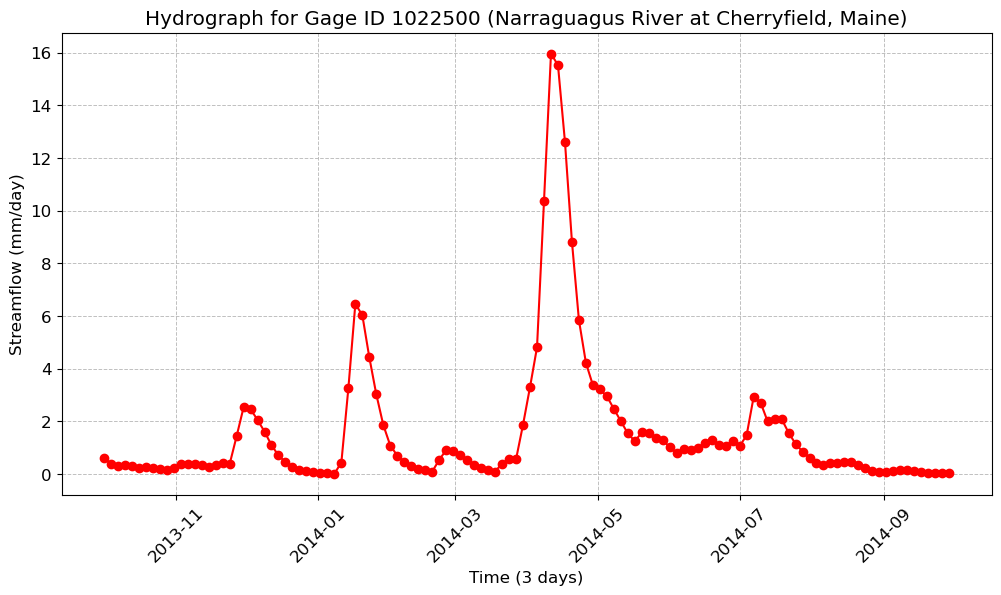

In [32]:
import numpy as np
import pandas as pd 
from src.dmg.core.data import txt_to_array   
from src.dmg.core.post import plot_hydrograph
from src.dmg.core.utils import Dates

#------------------------------------------#
# Choose a basin by USGS gage ID to plot.
GAGE_ID = 1022500
TARGET = 'streamflow'

# Resample to 3-day prediction. Options: 'D', 'W', 'M', 'Y'.
RESAMPLE = '3D'

# Set the paths to the gage ID lists...
GAGE_ID_PATH = config['observations']['gage_info']  # ./gage_id.npy
GAGE_ID_531_PATH = config['observations']['subset_path']  # ./531sub_id.txt

# Path to CAMELS gage names file
GAGE_NAME_PATH = "/beegfs/projects/aw-ciroh/common/datasets/camels/CAMELS_US/camels_attributes_v2.0/camels_name.txt"
#------------------------------------------#

# 1. Get the streamflow predictions and daily timesteps of the prediction window.
pred = output['Hbv_1_1p'][TARGET]
timesteps = Dates(config['simulation'], config['delta_model']['rho']).batch_daily_time_range
timesteps = timesteps[config['delta_model']['phy_model']['warm_up']:]  # remove warm-up period

# 2. Load the gage ID lists and get the basin index.
gage_ids = np.load(GAGE_ID_PATH, allow_pickle=True)
gage_ids_531 = txt_to_array(GAGE_ID_531_PATH)

if config['observations']['name'] == 'camels_671':
    basin_idx = list(gage_ids).index(GAGE_ID) if GAGE_ID in gage_ids else None
elif config['observations']['name'] == 'camels_531':
    basin_idx = list(gage_ids_531).index(GAGE_ID) if GAGE_ID in gage_ids_531 else None
else:
    raise ValueError(f"Unsupported dataset: {config['observations']}")

if basin_idx is None:
    raise ValueError(f"Gage ID {GAGE_ID} not found in dataset.")

# 3. Load gage names and look up this GAGE_ID 
gage_names = pd.read_csv(
    GAGE_NAME_PATH,
    sep=";",
    dtype={"gauge_id": str}
)

# normalize IDs: remove leading zeros
gage_names['gauge_id'] = gage_names['gauge_id'].str.lstrip('0')

# find the name
match = gage_names.loc[gage_names['gauge_id'] == str(GAGE_ID), 'gauge_name']

if match.empty:
    raise ValueError(f"GAGE_ID {GAGE_ID} not found in {GAGE_NAME_PATH}")
else:
    gage_name = match.values[0]

# 4. Get the data for the chosen basin and plot.
streamflow_pred_basin = pred[:, basin_idx].squeeze()

plot_hydrograph(
    timesteps,
    streamflow_pred_basin,
    resample=RESAMPLE,
    title=f"Hydrograph for Gage ID {GAGE_ID} ({gage_name})",
    ylabel='Streamflow (mm/day)',
)


<br>

## 2. Train δHBV 1.1p

After completing [these](#before-running) steps, train δHBV 1.1p with the code block below.

**Note**
- The settings defined in the config `./generic_deltamodel/example/conf/config_dhbv_1_1p.yaml` are set to replicate benchmark performance.
- For model training, set `mode: train` in the config, or modify after config dict has been created (see below).
- An `./example/generic_deltamodel/output/` directory will be generated to store experiment and model files. This location can be adjusted by changing the *save_path* key in your config. 
- Default settings with 50 epochs, batch size of 100, and training window from 1 October 1999 to 30 September 2008 should use ~2.8GB of vram. Expect training times of ~9 hours with an Nvidia RTX 3090 Ti.

In [ ]:
import sys
sys.path.append('../../')

from dmg import ModelHandler
from dmg.core.utils import (import_data_loader, import_trainer, print_config,
                            set_randomseed)
from example import load_config

#------------------------------------------#
# Define model settings here.
CONFIG_PATH = '../example/conf/config_dhbv_1_1p.yaml'
#------------------------------------------#

# 0. zhennan added --- tiny tee: mirror all prints/progress to train.log ---
from tqdm import tqdm
import sys

# tqdm writes to stderr by default; redirect to file also
logfile = open("train_progress.log", "a", buffering=1)

class TqdmLogger(object):
    def __init__(self, *files): self.files = files
    def write(self, x):
        for f in self.files:
            f.write(x)
            f.flush()
    def flush(self):
        for f in self.files: f.flush()

sys.stderr = TqdmLogger(sys.stderr, logfile)  # capture tqdm progress bar


# 1. Load configuration dictionary of model parameters and options.
config = load_config(CONFIG_PATH)
config['mode'] = 'train'
print_config(config)

# Set random seed for reproducibility.
set_randomseed(config['random_seed'])

# 2. Initialize the differentiable HBV 1.1p model (LSTM + HBV 1.1p) with model handler.
model = ModelHandler(config, verbose=True)

# 3. Load and initialize a dataset dictionary of NN and HBV model inputs.
data_loader_cls = import_data_loader(config['data_loader'])
data_loader = data_loader_cls(config, test_split=True, overwrite=False)


# 4. Initialize trainer to handle model training.
trainer_cls = import_trainer(config['trainer'])
trainer = trainer_cls(
    config,
    model,
    train_dataset=data_loader.train_dataset,
)

# 5. Start model training.
trainer.train()
print(f'Training complete. Model saved to \n{config['model_path']}')


Current Configuration
  Experiment Mode:    train               
  Model 1:            Hbv_1_1p            

Data Loader
  Data Source:        camels_531          
  Train Range :       1999/10/01          2008/09/30          

Model Parameters
  Train Epochs:       100                 Batch Size:         100                 
  Dropout:            0.5                 Hidden Size:        256                 
  Warmup:             365                 Concurrent Models:  16                  
  Loss Fn:            NseBatchLoss        

Machine
  Use Device:         cuda:0              



Epoch 1/100:  37%|###7      | 72/194 [06:04<10:11,  5.01s/it]

## 3. Evaluate Model Performance

After completing the training in [Section 1](#1-train-δhbv-11p), or with the trained model provided, test δHBV 1.1p below on the evaluation data.

**Note**
- For model evaluation, set `mode: test` in the config, or modify after config dict has been created (see below).
- When evaluating provided models, confirm that `test.test_epoch` in the config corresponds the training epochs completed for the model you want to test (e.g., 50 or 100).
- Default settings with 50 epochs, batch size of 25, and testing window from 1 October 1989 to 30 September 1999 should use ~2.7GB of VRAM. Expect evalutation times of ~5 minutes with an Nvidia RTX 3090 Ti.

### 3.1 Streamflow Simulation

In [3]:
import sys
sys.path.append('../../')

from dmg import ModelHandler
from dmg.core.utils import import_data_loader, import_trainer, print_config
from example import load_config

#------------------------------------------#
# Define model settings here.
CONFIG_PATH = '../example/conf/config_dhbv_1_1p.yaml'
#------------------------------------------#


# 1. Load configuration dictionary of model parameters and options.
config = load_config(CONFIG_PATH)
config['mode'] = 'test'
print_config(config)

set_randomseed(config['random_seed'])

# 2. Initialize the differentiable HBV 1.1p model (LSTM + HBV 1.1p).
model = ModelHandler(config, verbose=True)

# 3. Load and initialize a dataset dictionary of NN and HBV model inputs.
data_loader_cls = import_data_loader(config['data_loader'])
data_loader = data_loader_cls(config, test_split=True, overwrite=False)

# 4. Initialize trainer to handle model evaluation.
trainer_cls = import_trainer(config['trainer'])
trainer = trainer_cls(
    config,
    model,
    eval_dataset=data_loader.eval_dataset,
    verbose=True,
)

# 5. Start testing the model.
print('Evaluating model...')
trainer.evaluate()
print(f'Metrics and predictions saved to \n{config['out_path']}')


Current Configuration
  Experiment Mode:    test                
  Model 1:            Hbv_1_1p            

Data Loader
  Data Source:        camels_531          
  Test Range :        1989/10/01          1999/09/30          

Model Parameters
  Train Epochs:       50                  Batch Size:         100                 
  Dropout:            0.5                 Hidden Size:        256                 
  Warmup:             365                 Concurrent Models:  16                  
  Loss Fn:            NseBatchLoss        

Machine
  Use Device:         cuda:0              

Evaluating model...


Metrics and predictions saved to 
/beegfs/scratch/zhennanshi/DM/generic_deltamodel/extra_files_zhennan/test1989-1999_Ep100


### 3.2 Visualize Trained Model Performance

Once the model has been evaluated, a new directory (e.g., for a model trained for 50 epochs and tested from years 1989-1999), `test1989-1999_ep50/`, will be created in the same directory containing the model files. This path will be populated with...

1. All model outputs (fluxes, states), including the target variable, *streamflow* (`streamflow.npy`),

2. `streamflow_obs.npy`, streamflow observation data for comparison against model predictions,

2. `metrics.json`, containing evaluation metrics accross the test time range for every gage in the dataset,

3. `metrics_agg.json`, containing evaluation metric statistics across all sites (mean, median, standard deviation).

We can use these outputs to visualize δHBV 1.1p's performance with a 
1. Cumulative distribution function (CDF) plot, 

2. CONUS map of gage locations and metric (e.g., NSE) performance.

<br>

But first, let's first check the (basin-)aggregated metrics for NSE, KGE, bias, RMSE, and, for both high/low flow regimes, RMSE and absolute percent bias...

In [5]:
import os

from dmg.core.data import load_json
from dmg.core.post import print_metrics


print(f"Evaluation output files saved to: {config['out_path']} \n")

# 1. Load the basin-aggregated evaluation results.
metrics_path = os.path.join(config['out_path'], 'metrics_agg.json')
metrics = load_json(metrics_path)
print(f"Available metrics: {metrics.keys()} \n")

# 2. Print the evaluation results.
metric_names =  [
    # Choose metrics to show.
    'nse', 'kge', 'bias', 'rmse', 'rmse_low', 'rmse_high', 'flv_abs', 'fhv_abs',
]
print_metrics(metrics, metric_names, mode='median', precision=3)

Evaluation output files saved to: /beegfs/scratch/zhennanshi/DM/generic_deltamodel/extra_files_zhennan/test1989-1999_Ep100 

Available metrics: dict_keys(['bias', 'bias_rel', 'rmse', 'rmse_ub', 'rmse_fdc', 'mae', 'corr', 'corr_spearman', 'r2', 'nse', 'flv', 'fhv', 'pbias', 'pbias_mid', 'flv_abs', 'fhv_abs', 'pbias_abs', 'pbias_abs_mid', 'kge', 'kge_12', 'rmse_low', 'rmse_mid', 'rmse_high', 'd_max', 'd_max_rel']) 

Median of Metrics (Prec: 3 digits):
----------------------------------------
Nse: 0.757
Kge: 0.768
Bias: 0.469
Rmse: 1.217
Rmse_low: 0.055
Rmse_high: 3.315
Flv_abs: 37.868
Fhv_abs: 16.125
----------------------------------------


### 3.3 CDF Plot

The cumulative distribution function (CDF) plot tells us what percentage (CDF on the y-axis) of basins performed at least better than a given metric on the evaluation data.

An example is given below for NSE, but you can change to your preferred metric (see the output from the previous cell), but note some may require changing *xbounds* in `plot_cdf()`.

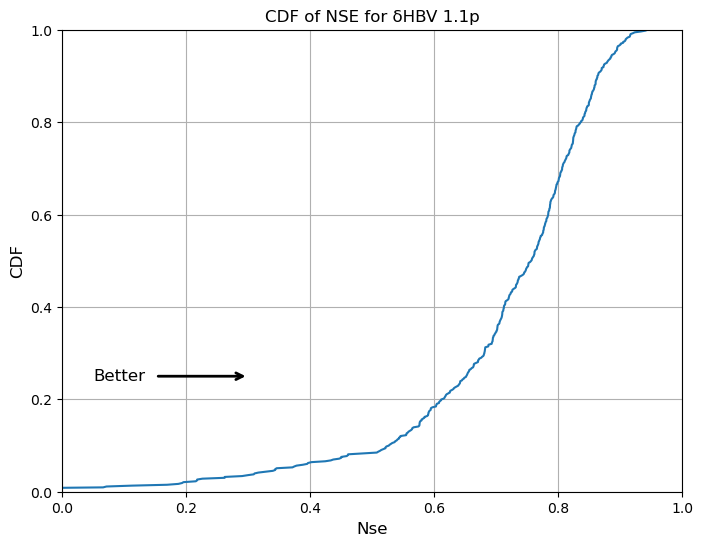

In [6]:
from dmg.core.post import plot_cdf

#------------------------------------------#
# Choose the metric to plot. (See available metrics printed above, or in the metrics_agg.json file).
METRIC = 'nse'
#------------------------------------------#


# 1. Load the evaluation metrics.
metrics_path = os.path.join(config['out_path'], 'metrics.json')
metrics = load_json(metrics_path)

# 2. Plot the CDF for NSE.
plot_cdf(
    metrics=[metrics],
    metric_names=[METRIC],
    model_labels=['δHBV 1.1p'],
    title="CDF of NSE for δHBV 1.1p",
    xlabel=METRIC.capitalize(),
    figsize=(8, 6),
    xbounds=(0, 1),
    ybounds=(0, 1),
    show_arrow=True,
)

### 3.4 Spatial Plot

This plot shows the locations of each basin in the evaluation data, color-coded by performance on a metric. Here we give a plot for NSE, but as before, this can be changed to your preference. (See above; for metrics not valued between 0 and 1, you will need to set `dynamic_colorbar=True` in `geoplot_single_metric` to ensure proper coding.)

Note, you will need to add paths to the CAMELS shapefile, gage IDs, and 531-gage subset which can be found in the [CAMELS download](#before-running).

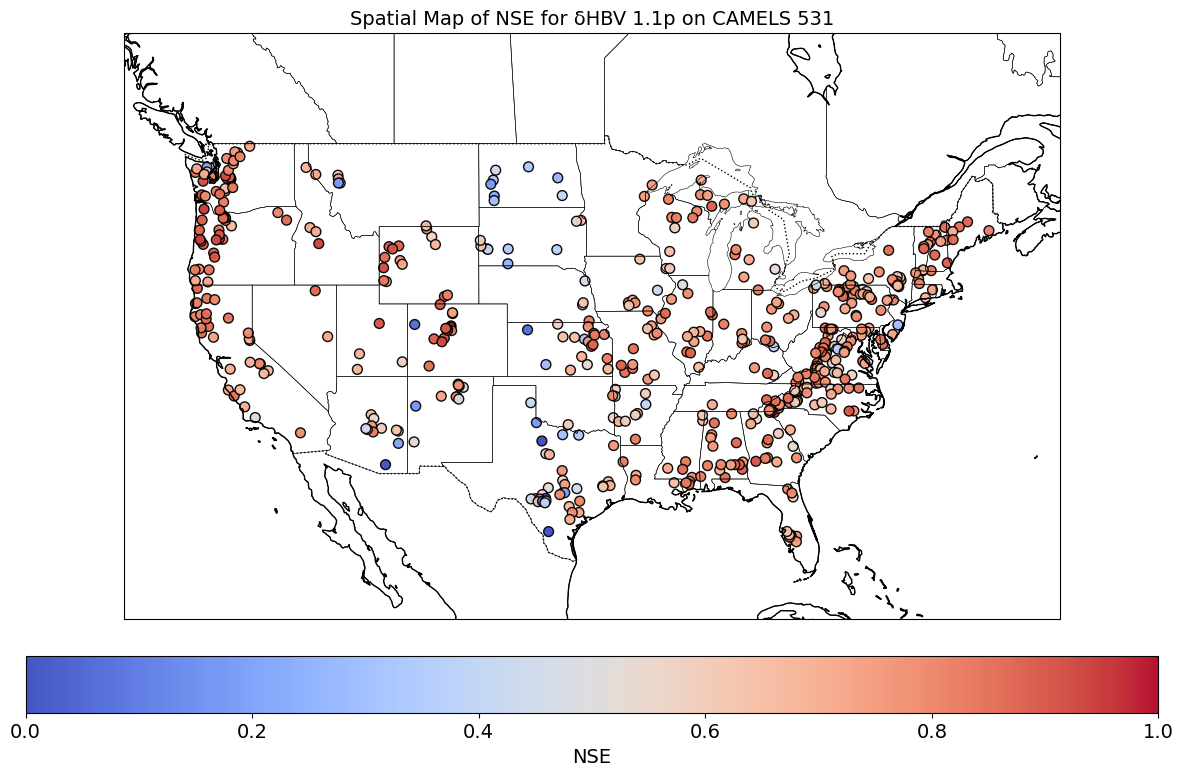

In [ ]:
import geopandas as gpd
import numpy as np
import pandas as pd

from dmg.core.data import txt_to_array
from dmg.core.post import geoplot_single_metric

#------------------------------------------#
# Choose the metric to plot. (See available metrics printed above, or in the metrics_agg.json file).
METRIC = 'nse'

# Set the paths to the gage id lists and shapefiles...
GAGE_ID_PATH = config['observations']['gage_info']  #./gage_id.npy
GAGE_ID_531_PATH = config['observations']['subset_path']  #./531sub_id.txt
SHAPEFILE_PATH = '/beegfs/scratch/zhennanshi/DM/generic_deltamodel/extra_files_zhennan/camels_loc/camels_671_loc.shp' ## zhennan added to his directory

#------------------------------------------#


# 1. Load gage ids + basin shapefile with geocoordinates (lat, long) for every gage.
gage_ids = np.load(GAGE_ID_PATH, allow_pickle=True)
gage_ids_531 = txt_to_array(GAGE_ID_531_PATH)
coords = gpd.read_file(SHAPEFILE_PATH)

# 2. Format geocoords for 531- and 671-basin CAMELS sets.
coords_531 = coords[coords['gage_id'].isin(list(gage_ids_531))].copy()

coords['gage_id'] = pd.Categorical(coords['gage_id'], categories=list(gage_ids), ordered=True)
coords_531['gage_id'] = pd.Categorical(coords_531['gage_id'], categories=list(gage_ids_531), ordered=True)

coords = coords.sort_values('gage_id')  # Sort to match order of metrics.
basin_coords_531 = coords_531.sort_values('gage_id')

# 3. Load the evaluation metrics.
metrics_path = os.path.join(config['out_path'], 'metrics.json')
metrics = load_json(metrics_path)

# 4. Add the evaluation metrics to the basin shapefile.
if config['observations']['name'] == 'camels_671':
    coords[METRIC] = metrics[METRIC]
    full_data = coords
elif config['observations']['name'] == 'camels_531':
    coords_531[METRIC] = metrics[METRIC]
    full_data = coords_531
else:
    raise ValueError(f"Observation data supported: 'camels_671' or 'camels_531'. Got: {config['observations']}")

# 5. Plot the evaluation results spatially.
geoplot_single_metric(
    full_data,
    METRIC,
    rf"Spatial Map of {METRIC.upper()} for δHBV 1.1p on CAMELS " \
        f"{config['observations']['name'].split('_')[-1]}",
    dynamic_colorbar=False,
)